# Market-Basket Analysis on IMDB Movies Dataset

---

## Overview
This project implements a market-basket analysis system to discover frequent actor co-occurrence patterns in the IMDB Top 1000 Movies dataset.

- **Baskets:** each movie is treated as one basket
- **Items:** the four billed actors (Star1, Star2, Star3, Star4)
- **Goal:** find frequent actor combinations and derive association rules

Three algorithms from the course are implemented and compared:
1. **A-Priori**: the classic multi-pass algorithm
2. **PCY (Park–Chen–Yu)**: A-Priori with a hash table on Pass 1 to filter candidate pairs
3. **SON (Savasere, Omiecinski & Navathe)**: splits data into chunks, mines locally, verifies globally

---

## 1. Setup and Dataset Download

In [ ]:
import os
import time
import itertools
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlxtend_apriori
from mlxtend.frequent_patterns import association_rules

In [ ]:
#Kaggle credentials
os.environ['KAGGLE_USERNAME'] = "chaimabenfredj"
os.environ['KAGGLE_KEY']      = "369a71030e2375a89405afcf433c3c92"

In [ ]:
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o imdb-dataset-of-top-1000-movies-and-tv-shows.zip

Archive:  imdb-dataset-of-top-1000-movies-and-tv-shows.zip
  inflating: imdb_top_1000.csv       


## 2. Data Loading and Pre-processing

In [ ]:
df = pd.read_csv("imdb_top_1000.csv")
print(f"Full dataset: {len(df)} rows")
df.head()

Full dataset: 1000 rows


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [ ]:
STAR_COLS = ['Star1', 'Star2', 'Star3', 'Star4']

def build_baskets(dataframe):
    baskets = []
    for _, row in dataframe.iterrows():
        actors = frozenset(row[col] for col in STAR_COLS if pd.notna(row[col]))
        baskets.append(actors)
    return baskets

baskets = build_baskets(df)
df_full = df.copy()

all_actors = []
for basket in baskets:
    for actor in basket:
        all_actors.append(actor)
print(f"Total baskets : {len(baskets)}")
print(f"Distinct actors: {len(set(all_actors))}")
print(f"Avg basket size: {len(all_actors)/len(baskets):.2f}")

# Convert baskets to a boolean matrix for mlxtend
transactions = [list(basket) for basket in baskets]
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
data_encoded = pd.DataFrame(te_array, columns=te.columns_)

Total baskets : 1000
Distinct actors: 2709
Avg basket size: 4.00


**Choosing a support threshold**

In [ ]:
s = int(0.005 * len(baskets))
print("Support threshold s =", s)

Support threshold s = 5


## 3. Algorithm 1: A-Priori

The A-Priori algorithm exploits the **monotonicity property**: if an itemset is frequent, all its subsets must also be frequent. It proceeds in passes:
- **Pass 1:** count singletons → find L1 (frequent items)
- **Pass 2:** count only pairs of frequent items → find L2
- **Pass 3+:** count triples whose pairs are all in L2, and so on

This avoids counting itemsets that cannot possibly be frequent.

In [ ]:
print(f"Running A-Priori with support = {s}")
t0 = time.time()
frequent_itemsets = mlxtend_apriori(data_encoded, min_support=s/len(baskets), use_colnames=True)
ap_time = time.time() - t0
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print(f"  Found {len(frequent_itemsets)} frequent itemsets in {ap_time:.4f}s")
frequent_itemsets.sort_values('support', ascending=False).head(10)

Running A-Priori with support = 5
  Found 83 frequent itemsets in 0.0245s


,support,itemsets,length
58,0.017,(Robert De Niro),1
71,0.014,(Tom Hanks),1
2,0.013,(Al Pacino),1
15,0.012,(Clint Eastwood),1
7,0.012,(Brad Pitt),1
13,0.011,(Christian Bale),1
49,0.011,(Leonardo DiCaprio),1
51,0.011,(Matt Damon),1
34,0.010,(James Stewart),1
41,0.009,(Johnny Depp),1


In [ ]:
L1 = frequent_itemsets[frequent_itemsets['length'] == 1].sort_values('support', ascending=False)
L2 = frequent_itemsets[frequent_itemsets['length'] == 2].sort_values('support', ascending=False)
L3 = frequent_itemsets[frequent_itemsets['length'] == 3].sort_values('support', ascending=False)
print(f"  L1: {len(L1)} frequent actors")
print(f"  L2: {len(L2)} frequent pairs")
print(f"  L3: {len(L3)} frequent triples")

  L1: 79 frequent actors
  L2: 3 frequent pairs
  L3: 1 frequent triples


### A-Priori Results

In [ ]:
print("Top 10 most frequent actors:")
for _, row in L1.head(10).iterrows():
    actor = list(row['itemsets'])[0]
    count = round(row['support'] * len(baskets))
    print(f"  {actor}: {count} movies")

Top 10 most frequent actors:
  Robert De Niro: 17 movies
  Tom Hanks: 14 movies
  Al Pacino: 13 movies
  Brad Pitt: 12 movies
  Clint Eastwood: 12 movies
  Matt Damon: 11 movies
  Christian Bale: 11 movies
  Leonardo DiCaprio: 11 movies
  James Stewart: 10 movies
  Denzel Washington: 9 movies


In [ ]:
print(f"Frequent pairs (support >= {s}):")
for _, row in L2.iterrows():
    actors = sorted(list(row['itemsets']))
    count = round(row['support'] * len(baskets))
    print(f"  {actors[0]} & {actors[1]}: {count} movies")

Frequent pairs (support >= 5):
  Daniel Radcliffe & Rupert Grint: 6 movies
  Daniel Radcliffe & Emma Watson: 5 movies
  Emma Watson & Rupert Grint: 5 movies


In [ ]:
print(f"Frequent triples (support >= {s}):")
for _, row in L3.iterrows():
    actors = sorted(list(row['itemsets']))
    count = round(row['support'] * len(baskets))
    print(f"  {tuple(actors)}: {count} movies")

Frequent triples (support >= 5):
  ('Daniel Radcliffe', 'Emma Watson', 'Rupert Grint'): 5 movies


## 4. Algorithm 2: PCY (Park–Chen–Yu)

PCY improves on A-Priori by using spare memory on **Pass 1** to maintain a hash table of pair counts. A pair is a **candidate** on Pass 2 only if:
1. Both items are in L1 (same as A-Priori), **and**
2. The pair hashes to a *frequent bucket* (bucket count ≥ support threshold)

This reduces the number of pairs to count on Pass 2.

In [ ]:
NUM_BUCKETS = 1009  # prime for better hash distribution

def pcy(baskets, support):
    t0 = time.time()
    frequent = {}

    # Pass 1: count actors and hash all pairs into buckets
    actor_counts = Counter()
    bucket_counts = [0] * NUM_BUCKETS

    for basket in baskets:
        items = list(basket)
        for a in items:
            actor_counts[a] += 1
        for pair in itertools.combinations(items, 2):
            h = hash(tuple(sorted(pair))) % NUM_BUCKETS
            bucket_counts[h] += 1

    L1 = {a for a, c in actor_counts.items() if c >= support}
    bitmap = [1 if c >= support else 0 for c in bucket_counts]

    freq_buckets = sum(bitmap)
    print(f"  Pass 1: {len(L1)} frequent actors, "
          f"{freq_buckets}/{NUM_BUCKETS} frequent buckets ({100*freq_buckets/NUM_BUCKETS:.1f}%)")

    # Pass 2: count pairs: both in L1 and hash to a frequent bucket
    pair_counts = Counter()
    for basket in baskets:
        freq_items = [a for a in basket if a in L1]
        for pair in itertools.combinations(freq_items, 2):
            key = tuple(sorted(pair))
            if bitmap[hash(key) % NUM_BUCKETS]:
                pair_counts[key] += 1

    L2 = {k: c for k, c in pair_counts.items() if c >= support}
    print(f"  Pass 2: {len(L2)} frequent pairs")
    frequent[1] = {(a,): actor_counts[a] for a in L1}
    frequent[2] = L2

    # Pass 3+: same candidate generation as APriori
    k = 3
    Lk = L2
    while Lk:
        prev = sorted(Lk)
        candidates = set()
        for i in range(len(prev)):
            for j in range(i + 1, len(prev)):
                a, b = prev[i], prev[j]
                if a[:-1] == b[:-1]:
                    new = tuple(sorted(set(a) | set(b)))
                    subs = [tuple(sorted(set(new) - {x})) for x in new]
                    if all(sub in Lk for sub in subs):
                        candidates.add(new)
        if not candidates:
            break
        cnt = Counter()
        for basket in baskets:
            for combo in itertools.combinations(sorted(basket), k):
                if combo in candidates:
                    cnt[combo] += 1
        Lk = {key: c for key, c in cnt.items() if c >= support}
        if Lk:
            frequent[k] = Lk
            print(f"  L{k}: {len(Lk)} frequent {k}-itemsets")
        k += 1

    print(f"  PCY time: {time.time() - t0:.4f}s")
    return frequent, time.time() - t0

In [ ]:
print(f"Running PCY with support = {s}")
pcy_results, pcy_time = pcy(baskets, s)

Running PCY with support = 5
  Pass 1: 79 frequent actors, 689/1009 frequent buckets (68.3%)
  Pass 2: 3 frequent pairs
  L3: 1 frequent 3-itemsets
  PCY time: 0.0081s


### PCY Results

In [ ]:
ap_pairs  = set(tuple(sorted(row['itemsets'])) for _, row in L2.iterrows())
pcy_pairs = set(pcy_results.get(2, {}).keys())

print(f"A-Priori frequent pairs : {len(ap_pairs)}")
print(f"PCY frequent pairs      : {len(pcy_pairs)}")
print(f"Sets are identical      : {ap_pairs == pcy_pairs}")

A-Priori frequent pairs : 3
PCY frequent pairs      : 3
Sets are identical      : True


## 5. Association Rules

From frequent itemsets we derive **association rules** of the form *I → j*.

For each rule we compute:
- **Support**: number of baskets containing I ∪ {j}
- **Confidence**: support(I ∪ {j}) / support(I)
- **Interest**: confidence − P(j), where P(j) = support({j}) / total baskets

In [ ]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.0)
rules = rules.sort_values('confidence', ascending=False)
rules = rules.rename(columns={'lift': 'interest'})

print(f"Total rules: {len(rules)}")
rules[['antecedents','consequents','support','confidence','interest']].head(20)

Total rules: 12


,antecedents,consequents,support,confidence,interest
3,(Rupert Grint),(Daniel Radcliffe),0.006,1.000000,166.666667
2,(Daniel Radcliffe),(Rupert Grint),0.006,1.000000,166.666667
8,"(Emma Watson, Rupert Grint)",(Daniel Radcliffe),0.005,1.000000,166.666667
6,"(Daniel Radcliffe, Emma Watson)",(Rupert Grint),0.005,1.000000,166.666667
11,(Rupert Grint),"(Daniel Radcliffe, Emma Watson)",0.005,0.833333,166.666667
0,(Daniel Radcliffe),(Emma Watson),0.005,0.833333,119.047619
7,"(Daniel Radcliffe, Rupert Grint)",(Emma Watson),0.005,0.833333,119.047619
5,(Rupert Grint),(Emma Watson),0.005,0.833333,119.047619
9,(Daniel Radcliffe),"(Emma Watson, Rupert Grint)",0.005,0.833333,166.666667
1,(Emma Watson),(Daniel Radcliffe),0.005,0.714286,119.047619


In [ ]:
print("Top rules by interest:")
rules.sort_values('interest', ascending=False)[['antecedents','consequents','support','confidence','interest']].head(10)

Top rules by interest:


,antecedents,consequents,support,confidence,interest
3,(Rupert Grint),(Daniel Radcliffe),0.006,1.000000,166.666667
2,(Daniel Radcliffe),(Rupert Grint),0.006,1.000000,166.666667
8,"(Emma Watson, Rupert Grint)",(Daniel Radcliffe),0.005,1.000000,166.666667
6,"(Daniel Radcliffe, Emma Watson)",(Rupert Grint),0.005,1.000000,166.666667
11,(Rupert Grint),"(Daniel Radcliffe, Emma Watson)",0.005,0.833333,166.666667
9,(Daniel Radcliffe),"(Emma Watson, Rupert Grint)",0.005,0.833333,166.666667
7,"(Daniel Radcliffe, Rupert Grint)",(Emma Watson),0.005,0.833333,119.047619
0,(Daniel Radcliffe),(Emma Watson),0.005,0.833333,119.047619
5,(Rupert Grint),(Emma Watson),0.005,0.833333,119.047619
1,(Emma Watson),(Daniel Radcliffe),0.005,0.714286,119.047619


## 6. Algorithm 3: SON (Savasere, Omiecinski & Navathe)

SON guarantees no false negatives by the following logic: if an itemset is frequent globally, it must appear frequently in at least one chunk (with a proportionally reduced threshold). The algorithm runs in two passes:

- **Pass 1:** split baskets into chunks, run A-Priori on each chunk with a reduced support, collect all local frequent itemsets as candidates
- **Pass 2:** count every candidate on the full dataset, keep those that meet the global support threshold

This structure maps naturally to MapReduce: chunks can be processed in parallel in Pass 1.

In [ ]:
def son(baskets, support, num_chunks=5):
    t0 = time.time()
    n = len(baskets)
    chunk_size = n // num_chunks

    # Pass 1: run A-Priori on each chunk with a reduced support
    candidates = set()
    for i in range(num_chunks):
        chunk = baskets[i * chunk_size : (i + 1) * chunk_size]
        local_support = max(2, round(support * len(chunk) / n))

        chunk_list = [list(basket) for basket in chunk]
        te_chunk = TransactionEncoder()
        te_array_chunk = te_chunk.fit(chunk_list).transform(chunk_list)
        chunk_encoded = pd.DataFrame(te_array_chunk, columns=te_chunk.columns_)

        local_freq = mlxtend_apriori(chunk_encoded, min_support=local_support/len(chunk), use_colnames=True)
        for itemset in local_freq['itemsets']:
            candidates.add(tuple(sorted(itemset)))

    print(f"  Candidates after Pass 1: {len(candidates)}")

    # Pass 2: count every candidate on the full dataset
    cnt = Counter()
    for basket in baskets:
        for cand in candidates:
            if set(cand).issubset(basket):
                cnt[cand] += 1

    frequent = {}
    for itemset, c in cnt.items():
        if c >= support:
            k = len(itemset)
            if k not in frequent:
                frequent[k] = {}
            frequent[k][itemset] = c

    total = sum(len(v) for v in frequent.values())
    print(f"  Globally frequent itemsets: {total}")
    print(f"  SON time: {time.time() - t0:.4f}s")
    return frequent, time.time() - t0

In [ ]:
print(f"Running SON with support = {s}")
son_results, son_time = son(baskets, s)

Running SON with support = 5
  Candidates after Pass 1: 378
  Globally frequent itemsets: 82
  SON time: 0.2188s


### SON Results

In [ ]:
son_pairs = set(son_results.get(2, {}).keys())
print(f"A-Priori pairs : {len(ap_pairs)}")
print(f"SON pairs      : {len(son_pairs)}")
print(f"Sets identical : {ap_pairs == son_pairs}")

A-Priori pairs : 3
SON pairs      : 3
Sets identical : True


## 7. Scalability Analysis

We run all three algorithms on 20%, 40%, 60%, 80%, and 100% of the dataset and record the wall-clock time. The support threshold is scaled proportionally to the subset size.

In [ ]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
ap_times, pcy_times, son_times, sizes = [], [], [], []

for frac in fractions:
    subset = df_full.sample(frac=frac, random_state=42)
    b_sub  = build_baskets(subset)
    s_sub  = max(2, round(s * frac))
    sizes.append(len(b_sub))

    print(f"── {int(frac*100)}% | {len(b_sub)} baskets | support={s_sub} ──")

    b_list = [list(basket) for basket in b_sub]
    te_sub = TransactionEncoder()
    data_sub = pd.DataFrame(te_sub.fit(b_list).transform(b_list), columns=te_sub.columns_)
    t0 = time.time()
    mlxtend_apriori(data_sub, min_support=s_sub/len(b_sub), use_colnames=True)
    ap_times.append(time.time() - t0)

    _, t = pcy(b_sub, s_sub)
    pcy_times.append(t)

    _, t = son(b_sub, s_sub)
    son_times.append(t)

── 20% | 200 baskets | support=2 ──
  Pass 1: 71 frequent actors, 341/1009 frequent buckets (33.8%)
  Pass 2: 10 frequent pairs
  L3: 3 frequent 3-itemsets
  PCY time: 0.0027s
  Candidates after Pass 1: 21
  Globally frequent itemsets: 21
  SON time: 0.0222s
── 40% | 400 baskets | support=2 ──
  Pass 1: 209 frequent actors, 679/1009 frequent buckets (67.3%)
  Pass 2: 29 frequent pairs
  L3: 6 frequent 3-itemsets
  PCY time: 0.0080s
  Candidates after Pass 1: 58
  Globally frequent itemsets: 58
  SON time: 0.0318s
── 60% | 600 baskets | support=3 ──
  Pass 1: 134 frequent actors, 684/1009 frequent buckets (67.8%)
  Pass 2: 13 frequent pairs
  L3: 1 frequent 3-itemsets
  PCY time: 0.0070s
  Candidates after Pass 1: 132
  Globally frequent itemsets: 90
  SON time: 0.0569s
── 80% | 800 baskets | support=4 ──
  Pass 1: 104 frequent actors, 690/1009 frequent buckets (68.4%)
  Pass 2: 4 frequent pairs
  L3: 1 frequent 3-itemsets
  PCY time: 0.0096s
  Candidates after Pass 1: 232
  Globally fr

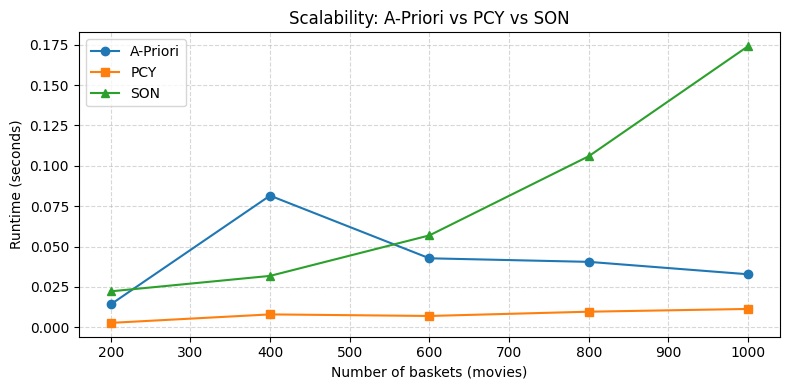

 Fraction  Baskets  A-Priori time(s)  PCY time(s)  SON time(s)
      0.2      200           0.01413      0.00272      0.02225
      0.4      400           0.08153      0.00797      0.03182
      0.6      600           0.04272      0.00700      0.05689
      0.8      800           0.04051      0.00964      0.10593
      1.0     1000           0.03282      0.01135      0.17409


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(sizes, ap_times,  marker='o', label='A-Priori')
plt.plot(sizes, pcy_times, marker='s', label='PCY')
plt.plot(sizes, son_times, marker='^', label='SON')
plt.xlabel('Number of baskets (movies)')
plt.ylabel('Runtime (seconds)')
plt.title('Scalability: A-Priori vs PCY vs SON')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

scale_df = pd.DataFrame({
    'Fraction': fractions,
    'Baskets': sizes,
    'A-Priori time(s)': [round(t, 5) for t in ap_times],
    'PCY time(s)': [round(t, 5) for t in pcy_times],
    'SON time(s)': [round(t, 5) for t in son_times],
})
print(scale_df.to_string(index=False))

## 8. Results Summary and Discussion

In [ ]:
print("=" * 55)
print(f" Results (full dataset, support >= {s})")
print("=" * 55)
for length in sorted(frequent_itemsets['length'].unique()):
    n = len(frequent_itemsets[frequent_itemsets['length'] == length])
    print(f"  L{length}: {n} frequent {length}-itemsets")

print()
print(f"  A-Priori: {ap_time:.4f}s")
print(f"  PCY : {pcy_time:.4f}s")
print(f"  SON : {son_time:.4f}s")

print("Frequent actor pairs:")
for _, row in L2.iterrows():
    actors = sorted(list(row['itemsets']))
    count = round(row['support'] * len(baskets))
    print(f"  {actors[0]} & {actors[1]}: {count} movies")

print("Frequent actor triples:")
for _, row in L3.iterrows():
    actors = sorted(list(row['itemsets']))
    count = round(row['support'] * len(baskets))
    print(f"  {tuple(actors)}: {count} movies")

print("Top 10 association rules by confidence:")
print(rules[['antecedents','consequents','support','confidence','interest']].head(10).to_string(index=False))

 Results (full dataset, support >= 5)
  L1: 79 frequent 1-itemsets
  L2: 3 frequent 2-itemsets
  L3: 1 frequent 3-itemsets

  A-Priori: 0.0245s
  PCY : 0.0081s
  SON : 0.2188s
Frequent actor pairs:
  Daniel Radcliffe & Rupert Grint: 6 movies
  Daniel Radcliffe & Emma Watson: 5 movies
  Emma Watson & Rupert Grint: 5 movies
Frequent actor triples:
  ('Daniel Radcliffe', 'Emma Watson', 'Rupert Grint'): 5 movies
Top 10 association rules by confidence:
                     antecedents                     consequents  support  confidence   interest
                  (Rupert Grint)              (Daniel Radcliffe)    0.006    1.000000 166.666667
              (Daniel Radcliffe)                  (Rupert Grint)    0.006    1.000000 166.666667
     (Emma Watson, Rupert Grint)              (Daniel Radcliffe)    0.005    1.000000 166.666667
 (Daniel Radcliffe, Emma Watson)                  (Rupert Grint)    0.005    1.000000 166.666667
                  (Rupert Grint) (Daniel Radcliffe, Emma Watson

### **Discussion**

**Frequent itemsets:** The most frequent actors in the top 1000 IMDB movies are mostly well-known Hollywood names: Robert De Niro, Tom Hanks, Al Pacino. Not a huge surprise given the dataset. The more interesting result is in the pairs and triples: Daniel Radcliffe, Emma Watson, and Rupert Grint dominate, appearing together in 5–6 movies. That's entirely driven by the Harry Potter franchise, which makes sense but also means the "association" here is really just co-casting in a series.

**Association rules:** The highest-confidence rules are things like `{Rupert Grint} → {Daniel Radcliffe}` and vice versa, both at confidence 1.0. That means every time Grint appears in the dataset, Radcliffe is there too. The interest of 166.67 confirms this isn't random: Radcliffe is 166 times more likely to appear alongside Grint than you'd expect by chance. In practice, these rules don't tell us much beyond "they were in the same franchise," but they do validate that the algorithm is picking up real patterns.

**A-Priori vs PCY:** PCY was faster than A-Priori at every dataset size tested: 0.003s vs 0.014s at 200 baskets, 0.011s vs 0.033s at 1000. The difference comes from Pass 1: PCY uses the extra memory to hash pairs into buckets and can eliminate candidates before even counting them in Pass 2. On a dataset this small the gap is modest, but it would grow at larger scales where the number of candidate pairs explodes.

**SON:** SON splits the data into chunks, mines frequent itemsets locally with a reduced support threshold, then verifies the union of candidates on the full dataset. It found the same pairs and triple as A-Priori (Sets identical: True), which is expected: SON is designed to have no false negatives. The runtime was noticeably higher though (0.174s at 1000 baskets vs 0.011s for PCY), which makes sense: you're running multiple local passes plus a full global counting pass. At 1000 movies that overhead isn't worth it, but the two-pass structure maps to MapReduce, so the payoff would come at much larger scales with parallel chunk processing.

**Scalability:** PCY scales the most smoothly across all fractions tested. SON's growth is steeper, mostly due to the local+global pass overhead mentioned above. A-Priori sits in the middle. The current dataset is too small to really stress-test these differences: the rankings might shift with a dataset 10–100x larger.